In [20]:
# Import some libraries
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt, numpy as np, os
from fredapi import Fred
from bls import get_series


In [21]:
# load APIs
from dotenv import load_dotenv
load_dotenv()

# Configure FRED and BLS API keys
API_KEY = os.getenv('FRED_API_KEY')
# os.environ['BLS_API_KEY'] = os.getenv('BLS_API_KEY')

# Initialize FRED API
fred = Fred(api_key=API_KEY)

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/gdp-revisions.csv', index_col=0, parse_dates=True)
# Date, GDPPercentAug, GDPPercentSept, GDIPercentAug, GDPPercentSept
df['Date'] = df.index
df = df[df['Date'] >= '2022-01-01']  # Filter from the specified date onwards

title = 'GDP and GDI Revisions from August to September'
x_label = 'Date'
y_label = 'Percent Change'
legend_loc = 'upper left'


In [23]:
df.head()

,GDPPercentAug,GDPPercentSept,GDIPercentAug,GDIPercentSept,Date
Date,,,,,
2022-01-01,-2.0,-1.0,0.0,1.0,2022-01-01
2022-04-01,-0.6,0.3,0.0,1.0,2022-04-01
2022-07-01,2.7,2.7,0.1,1.6,2022-07-01
2022-10-01,2.6,3.4,-0.1,1.3,2022-10-01
2023-01-01,2.2,2.8,1.6,2.9,2023-01-01


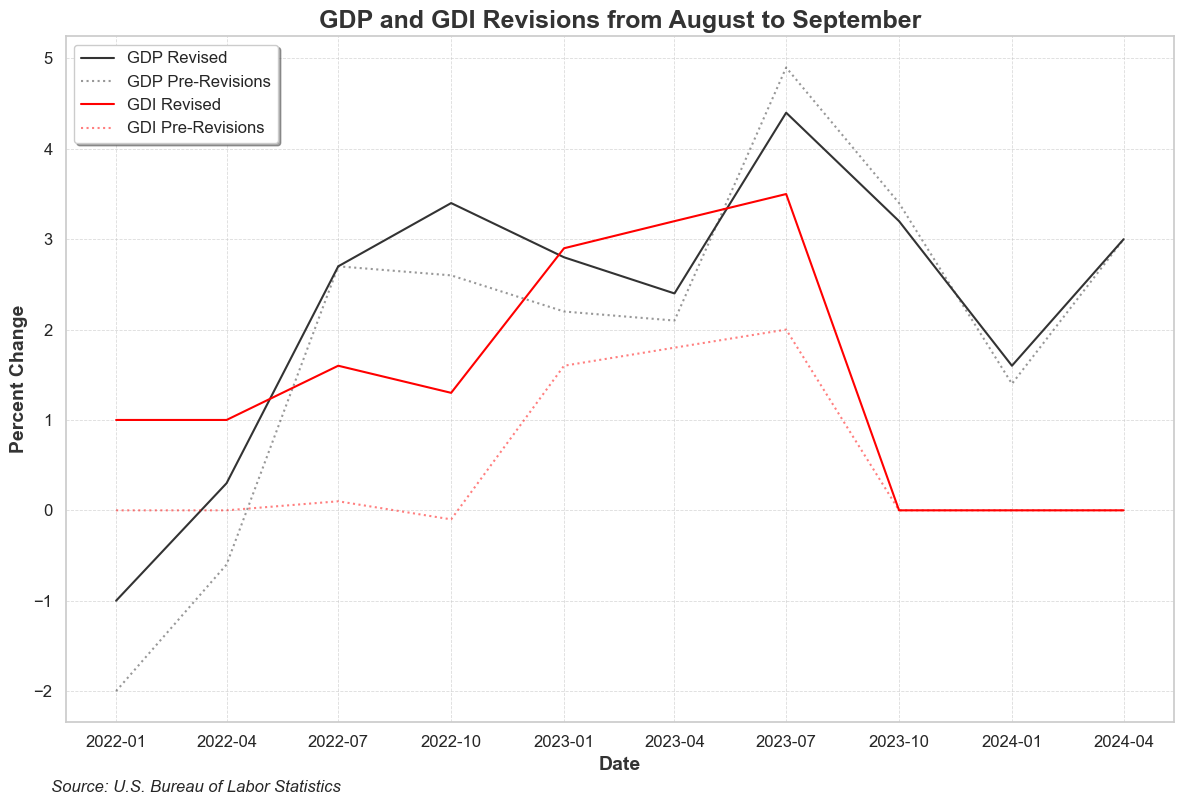

In [24]:
# Set up the style using seaborn
sns.set(style="whitegrid", palette="dark")

# Create a figure and axis with a larger size for better aesthetics
plt.figure(figsize=(12, 8))

# Plot each series
# make Aug data faded dotted line and Sept data solid line
# GDP and GDI should be different colors
plt.plot(df.index, df['GDPPercentSept'], label='GDP Revised', color='#333333', linestyle='-')
plt.plot(df.index, df['GDPPercentAug'], label='GDP Pre-Revisions', color='#333333', linestyle=':', alpha=0.5)
plt.plot(df.index, df['GDIPercentSept'], label='GDI Revised', color='red', linestyle='-')
plt.plot(df.index, df['GDIPercentAug'], label='GDI Pre-Revisions', color='red', linestyle=':', alpha=0.5)

# Enhance the title and labels
plt.title(title, fontsize=18, weight='bold', color='#333333')
plt.xlabel(x_label, fontsize=14, weight='bold', color='#333333')
plt.ylabel(y_label, fontsize=14, weight='bold', color='#333333')

# Rotate the x-axis labels for better readability and adjust their size
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Add a grid with more customization
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

# Show the legend with a custom location and background
plt.legend(loc=legend_loc, frameon=True, fontsize=12, fancybox=True, shadow=True)

# Check which source it has
# Add a footer with the source of the data
plt.figtext(0.17, 0, 'Source: U.S. Bureau of Labor Statistics', ha="center", fontsize=12, style='italic')
    
# Tighten layout to make the plot look cleaner
plt.tight_layout()

# Display the plot
plt.show()

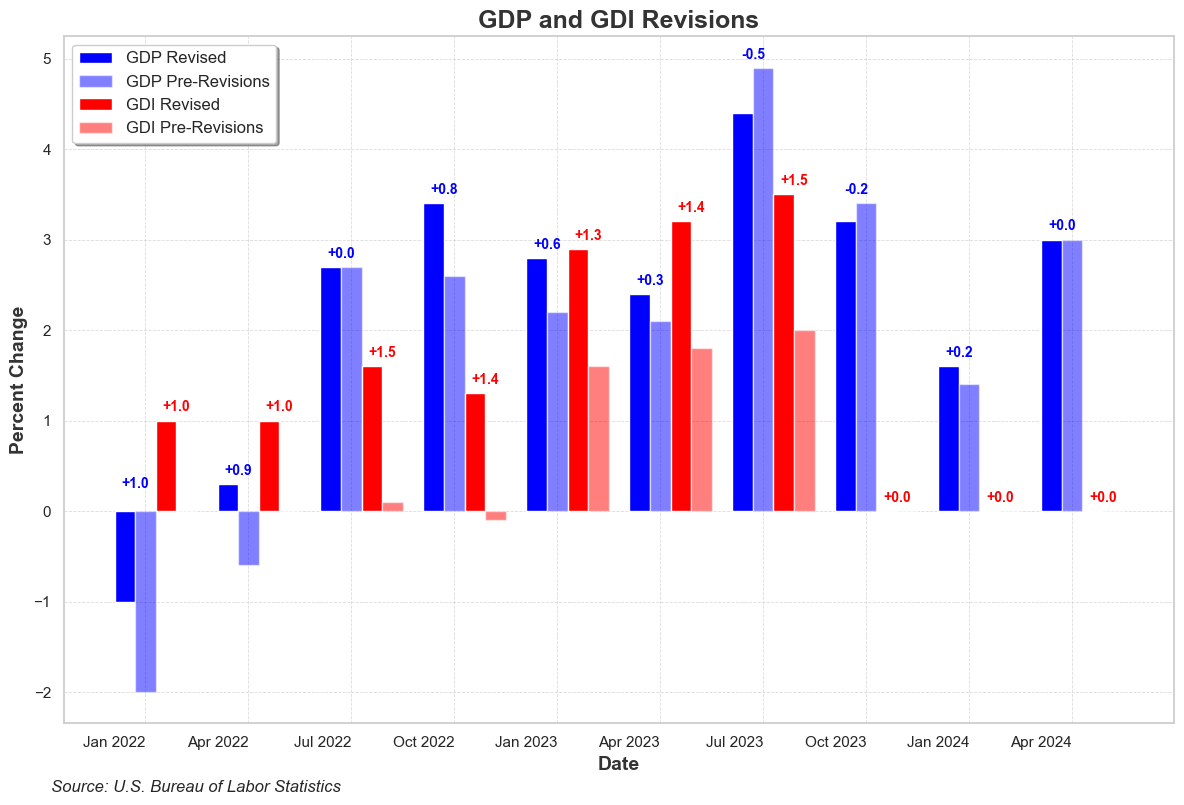

In [25]:
# Set up the style using seaborn
sns.set(style="whitegrid", palette="dark")

# Create a figure and axis with a larger size for better aesthetics
plt.figure(figsize=(12, 8))

# Set the width of the bars
bar_width = 0.2

# Set the position of bars on the x-axis
r1 = np.arange(len(df))
r2 = [x + bar_width for x in r1]  # Shift GDP Pre-Revisions right
r3 = [x + bar_width for x in r2]  # Shift GDI Revised further right
r4 = [x + bar_width for x in r3]  # Shift GDI Pre-Revisions further right

# Plot GDP and GDI data side by side for Aug and Sept
bars1 = plt.bar(r1, df['GDPPercentSept'], width=bar_width, label='GDP Revised', color='blue')
bars2 = plt.bar(r2, df['GDPPercentAug'], width=bar_width, label='GDP Pre-Revisions', color='blue', alpha=0.5)
bars3 = plt.bar(r3, df['GDIPercentSept'], width=bar_width, label='GDI Revised', color='red')
bars4 = plt.bar(r4, df['GDIPercentAug'], width=bar_width, label='GDI Pre-Revisions', color='red', alpha=0.5)

# Enhance the title and labels
plt.title("GDP and GDI Revisions", fontsize=18, weight='bold', color='#333333')
plt.xlabel("Date", fontsize=14, weight='bold', color='#333333')
plt.ylabel("Percent Change", fontsize=14, weight='bold', color='#333333')

# Manually create formatted x-axis labels
x_labels = pd.to_datetime(df.index).strftime('%b %Y')  # Convert to "Month Year" format

# Set the ticks and labels on the x-axis manually
plt.xticks([r + bar_width for r in range(len(df))], x_labels, rotation=0, ha='right')

# Annotate the bars with the difference between Revised and Pre-Revisions
for i, index in enumerate(df.index):
    # Calculate the difference between revised and pre-revised values for GDP and GDI
    gdp_diff = df['GDPPercentSept'].iloc[i] - df['GDPPercentAug'].iloc[i]
    gdi_diff = df['GDIPercentSept'].iloc[i] - df['GDIPercentAug'].iloc[i]
    
    # Place the GDP difference above the blue bars
    plt.text(r1[i] + bar_width/2, max(df['GDPPercentSept'].iloc[i], df['GDPPercentAug'].iloc[i]) + 0.1 if i != 0 else 0.25, 
             f'{gdp_diff:+.1f}', ha='center', fontsize=10, color='blue', fontweight='bold')

    # Place the GDI difference above the red bars
    plt.text(r3[i] + bar_width/2, max(df['GDIPercentSept'].iloc[i], df['GDIPercentAug'].iloc[i]) + 0.1, 
             f'{gdi_diff:+.1f}', ha='center', fontsize=10, color='red', fontweight='bold')

# Add a grid with more customization
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

# Show the legend with a custom location and background
plt.legend(loc="upper left", frameon=True, fontsize=12, fancybox=True, shadow=True)

# Add a footer with the source of the data
plt.figtext(0.17, 0, 'Source: U.S. Bureau of Labor Statistics', ha="center", fontsize=12, style='italic')

# Tighten layout to make the plot look cleaner
plt.tight_layout()

# Display the plot
plt.show()


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/foreign-born.csv', index_col=0, parse_dates=True)
# Date, GDPPercentAug, GDPPercentSept, GDIPercentAug, GDPPercentSept
df['Date'] = df.index
df = df[df['Date'] >= '2014-01-01']  # Filter from the specified date onwards

title = 'Foreign Born Workers Boost US Labor Supply'
x_label = 'Date'
y_label = 'Millions of Workers'
legend_loc = 'upper left'


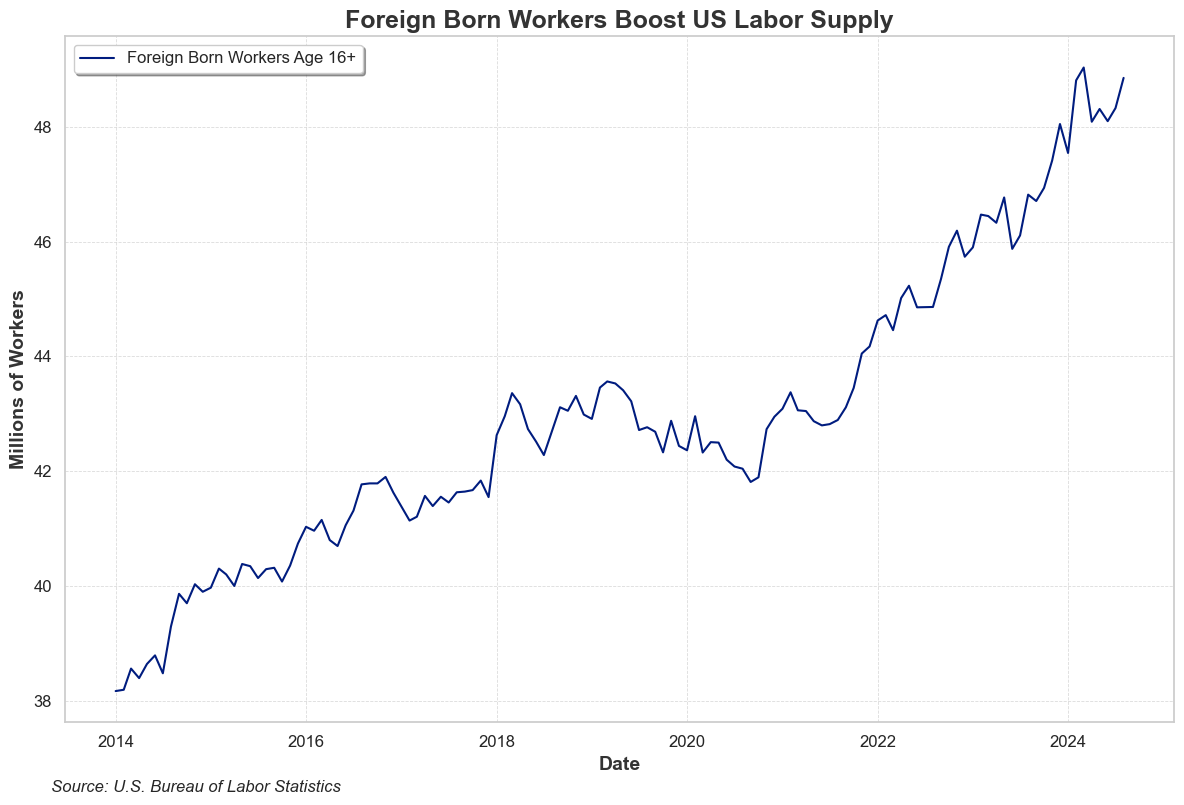

In [27]:
# Set up the style using seaborn
sns.set(style="whitegrid", palette="dark")

# Create a figure and axis with a larger size for better aesthetics
plt.figure(figsize=(12, 8))

# Plot each series
# make Aug data faded dotted line and Sept data solid line
# GDP and GDI should be different colors
plt.plot(df.index, df['Millions'], label='Foreign Born Workers Age 16+', linestyle='-')

# Enhance the title and labels
plt.title(title, fontsize=18, weight='bold', color='#333333')
plt.xlabel(x_label, fontsize=14, weight='bold', color='#333333')
plt.ylabel(y_label, fontsize=14, weight='bold', color='#333333')

# Rotate the x-axis labels for better readability and adjust their size
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Add a grid with more customization
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

# Show the legend with a custom location and background
plt.legend(loc=legend_loc, frameon=True, fontsize=12, fancybox=True, shadow=True)

# Check which source it has
# Add a footer with the source of the data
plt.figtext(0.17, 0, 'Source: U.S. Bureau of Labor Statistics', ha="center", fontsize=12, style='italic')
    
# Tighten layout to make the plot look cleaner
plt.tight_layout()

# Display the plot
plt.show()

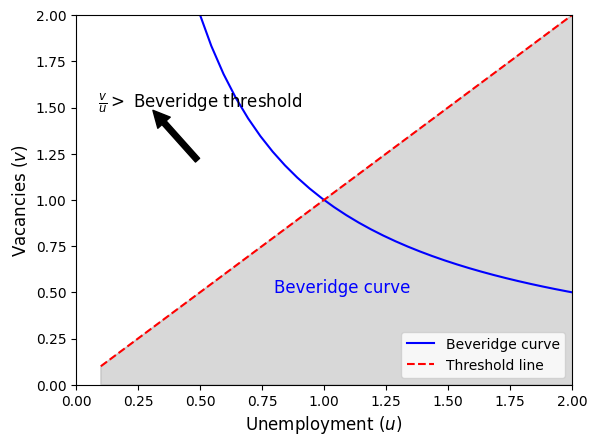

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Create the figure and axis
fig, ax = plt.subplots()

# Define unemployment and vacancies data (for illustrative purposes)
u = np.linspace(0.1, 5, 100)
v = 1 / u  # Beveridge curve (inverse relationship)

# Plot Beveridge curve
ax.plot(u, v, color='blue', label='Beveridge curve')

# Add red dashed line for the threshold (y=x line)
ax.plot(u, u, 'r--', label='Threshold line')

# Add a shaded region
ax.fill_between(u, u, color='gray', alpha=0.3)

# Add labels and annotation
ax.text(0.5, 1.5, r'$\frac{v}{u} >$ Beveridge threshold', fontsize=12, ha='center')
ax.annotate('', xy=(0.3, 1.5), xytext=(0.5, 1.2),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Labels for axes
ax.set_xlabel('Unemployment $(u)$', fontsize=12)
ax.set_ylabel('Vacancies $(v)$', fontsize=12)

# Add title and other text
ax.text(0.8, 0.5, 'Beveridge curve', color='blue', fontsize=12)
ax.legend()

# Set limits for better visuals
ax.set_xlim([0, 2])
ax.set_ylim([0, 2])

# Save the plot as SVG
plt.savefig('beveridge_curve.svg', format='svg')

# Show the plot
plt.show()


In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Import some libraries
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt, numpy as np, os
from fredapi import Fred
from bls import get_series

# load APIs
from dotenv import load_dotenv
load_dotenv()

# Configure FRED and BLS API keys
API_KEY = os.getenv('FRED_API_KEY')
# os.environ['BLS_API_KEY'] = os.getenv('BLS_API_KEY')

# Initialize FRED API
fred = Fred(api_key=API_KEY)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Plot grouped bar graph for FRED or BLS data
def plot_grouped_bars(series_dict, title, legend_text_generator, from_date='2000-01-01', x_label='Date', y_label='Series Value', 
                      change_in=False, percent_change=False, year_over_year=False, periods_in_year=None,
                      custom_text='Source: Federal Reserve Economic Data'):
    """
    Fetches and plots multiple FRED or BLS series as a grouped bar graph.
    
    Parameters:
    - series_dict: Dictionary where keys are series IDs and values are the source ('FRED' or 'BLS')
    - title: The title of the plot
    - legend_text_generator: A list that provides custom text for the legend for each series
    - from_date: The starting date for the series (default is '2000-01-01')
    - x_label: The label for the x-axis (default is 'Date')
    - y_label: The label for the y-axis (default is 'Series Value')
    - change_in: Whether to calculate the difference or percentage change (default False)
    - percent_change: Whether to calculate percentage change instead of raw differences (default False)
    - year_over_year: Whether to calculate year-over-year percentage change (default False)
    """
    # Initialize an empty DataFrame for merging
    merged_df = pd.DataFrame()

    # Fetch each series and merge
    for idx, (series_id, source) in enumerate(series_dict.items()):
        # Fetch data from the source (FRED or BLS)
        if source == 'FRED':
            try:
                data = fred.get_series(series_id)
            except Exception as e:
                raise ValueError(f"Error fetching FRED series {series_id}: {e}")
        elif source == 'BLS':
            try:
                unformatted_data = get_series(series_id)  # Assuming get_series fetches BLS data
                x = unformatted_data.index.to_timestamp()
                y = unformatted_data.values
                data = pd.Series(y, index=x)
            except Exception as e:
                raise ValueError(f"Error fetching BLS series {series_id}: {e}")
        elif source == 'FILE':
            df = pd.read_csv(series_id, index_col=0, parse_dates=True)
            data = df['Value']
        else:
            raise ValueError(f"Invalid source '{source}' for series {series_id}. Use 'FRED', 'BLS', or 'FILE'.")

        # Create DataFrame from the fetched data
        df = pd.DataFrame(data, columns=[legend_text_generator[idx]])
        df['Date'] = df.index
        df = df[df['Date'] >= from_date]

        # Merge into the main DataFrame
        if merged_df.empty:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on="Date", how="inner")

    # Set up the style using seaborn
    sns.set(style="whitegrid", palette="dark")

    # Create a figure and axis with a larger size for better aesthetics
    plt.figure(figsize=(12, 8))

    # Set the width of the bars
    bar_width = 0.2

    # Create positions for each series' bars
    r = [np.arange(len(merged_df))]  # Starting position for the first group
    for i in range(1, len(series_dict)):
        r.append([x + bar_width for x in r[-1]])  # Shift the bars right for each additional series

    # Plot each series as bars
    for idx, series in enumerate(legend_text_generator):
        plt.bar(r[idx], merged_df[series], width=bar_width, label=series)

    # Enhance the title and labels
    plt.title(title, fontsize=18, weight='bold', color='#333333')
    plt.xlabel(x_label, fontsize=14, weight='bold', color='#333333')
    plt.ylabel(y_label, fontsize=14, weight='bold', color='#333333')

    # Manually create formatted x-axis labels
    x_labels = [date.strftime('%b %Y') for date in pd.to_datetime(merged_df['Date'])]

    # Set the ticks and labels on the x-axis manually
    plt.xticks([r_i + bar_width for r_i in range(len(merged_df))], x_labels, rotation=45, ha='right')

    # Add a grid with more customization
    plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

    # Show the legend with a custom location
    plt.legend(loc="upper right", frameon=True, fontsize=12, fancybox=True, shadow=True)

    # Add a footer with the source of the data
    if 'FRED' in series_dict.values() and 'BLS' in series_dict.values():
        plt.figtext(0.27, 0, 'Source: Federal Reserve Economic Data and U.S. Bureau of Labor Statistics', ha="center", fontsize=12, style='italic')
    elif 'FRED' in series_dict.values():
        plt.figtext(0.17, 0, 'Source: Federal Reserve Economic Data', ha="center", fontsize=12, style='italic')
    elif 'BLS' in series_dict.values():
        plt.figtext(0.17, 0, 'Source: U.S. Bureau of Labor Statistics', ha="center", fontsize=12, style='italic')
    else:
        plt.figtext(0.17, 0, custom_text, ha="center", fontsize=12, style='italic')

    # Tighten layout
    plt.tight_layout()

    # Display the plot
    plt.show()


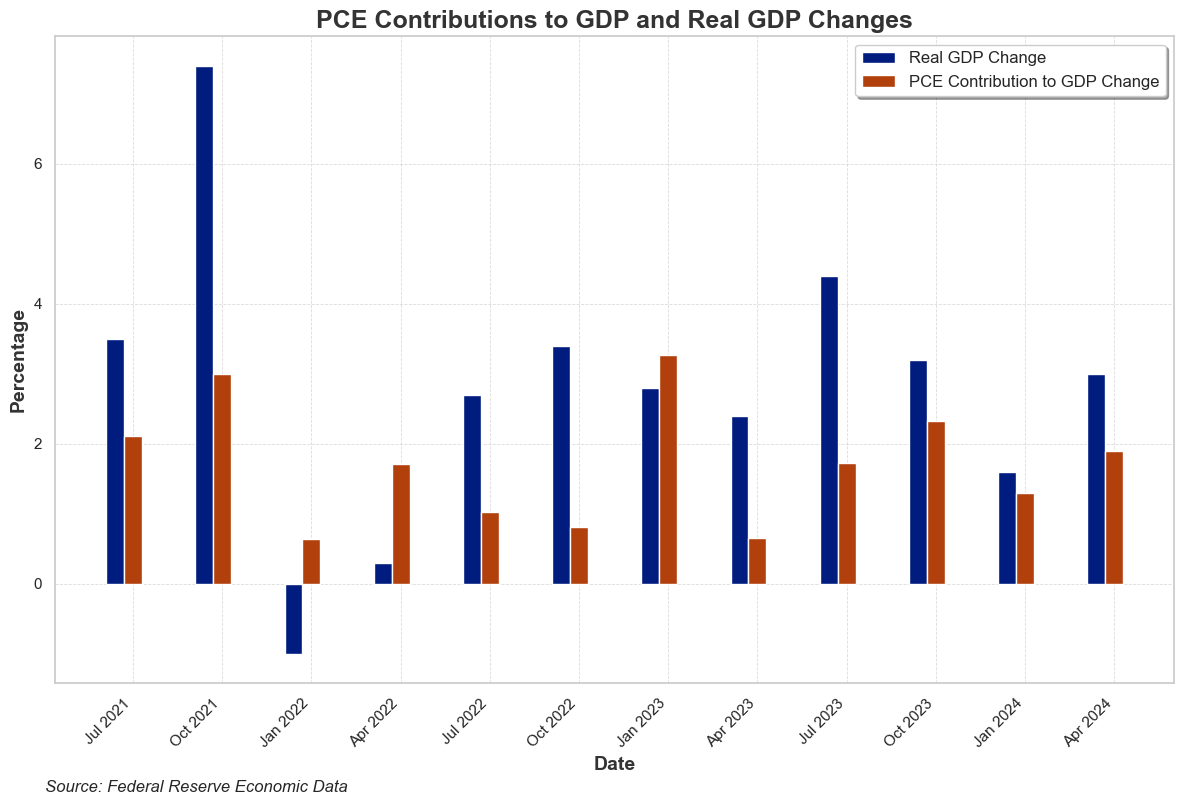

In [29]:
# run plot_series_bar function
series_dict = {  # Unemployment rate
    'A191RL1Q225SBEA': 'FRED',
    'DPCERY2Q224SBEA': 'FRED',  # Job openings
}

legend = ['Real GDP Change', 'PCE Contribution to GDP Change', ]


plot_grouped_bars(series_dict, 'PCE Contributions to GDP and Real GDP Changes', legend, from_date='2021-07-01', y_label='Percentage')